
TEST 1: random X and Y
my LS: m=-0.043588, b=0.592710
numpy LS: m=-0.043588, b=0.592710
diff: |dm|=2.57e-16, |db|=2.22e-16


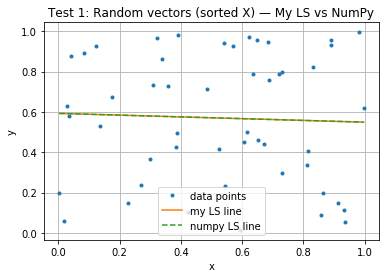


TEST 2: y = mx + b +/- noise
true line: m=2.500000, b=-0.400000
my LS: m=2.479670, b=-0.346344
numpy LS: m=2.479670, b=-0.346344
diff: |dm|=8.88e-16, |db|=8.88e-16
Residuals:
  largest  = 0.947396 at x=0.94, y=2.931943
  smallest = -1.034140 at x=0.71, y=0.380083


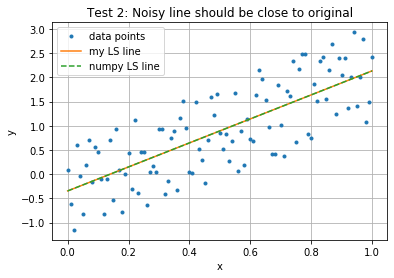

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def my_ls_line(x, y):
    """
    my own least squares line fit (the slide formula version)
    returns m, b for y = m x + b
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    # sums we need (literally the Σ stuff from the slides)
    Sx  = np.sum(x)
    Sy  = np.sum(y)
    Sxx = np.sum(x * x)
    Sxy = np.sum(x * y)

    # denominator (if this is 0, the math breaks so that usually means x values are all the same)
    denom = n * Sxx - Sx**2
    if np.isclose(denom, 0.0):
        raise ValueError("denominator is ~0 (your x values are weird / all the same)")

    # slope and intercept formulas
    m = (n * Sxy - Sx * Sy) / denom
    b = (Sy - m * Sx) / n
    return m, b


def numpy_ls_line(x, y):
    """
    numpy version using the design matrix [x  1]
    returns m, b for y = m x + b
    """
    A = np.vstack([x, np.ones(len(x))]).T
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return m, b


def get_residuals(x, y, m, b):
    # residual = actual y - predicted y
    return y - (m * x + b)


def print_biggest_smallest_residual(x, y, r):
    # biggest residual = most positive (point above the line)
    # smallest residual = most negative (point below the line)
    i_max = np.argmax(r)
    i_min = np.argmin(r)

    print("Residuals:")
    print(f"  largest  = {r[i_max]:.6f} at x={x[i_max]:.2f}, y={y[i_max]:.6f}")
    print(f"  smallest = {r[i_min]:.6f} at x={x[i_min]:.2f}, y={y[i_min]:.6f}")


def plot_points_and_lines(x, y, m_my, b_my, m_np, b_np, title):
    # making a smooth x range so the line looks clean
    x_line = np.linspace(np.min(x), np.max(x), 300)

    # predicted lines
    y_my = m_my * x_line + b_my
    y_np = m_np * x_line + b_np

    plt.figure()
    plt.plot(x, y, "o", markersize=3, label="data points")
    plt.plot(x_line, y_my, "-", label="my LS line")
    plt.plot(x_line, y_np, "--", label="numpy LS line")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# testing my LS on random vectors X and Y 

rng = np.random.default_rng(0)

Xr = rng.random(50)   # random X
Yr = rng.random(50)   # random Y

# said to sort x
idx = np.argsort(Xr)
Xr = Xr[idx]
Yr = Yr[idx]  # keep points paired so the plot makes sense

m_my1, b_my1 = my_ls_line(Xr, Yr)
m_np1, b_np1 = numpy_ls_line(Xr, Yr)

print("\nTEST 1: random X and Y")
print(f"my LS: m={m_my1:.6f}, b={b_my1:.6f}")
print(f"numpy LS: m={m_np1:.6f}, b={b_np1:.6f}")
print(f"diff: |dm|={abs(m_my1-m_np1):.2e}, |db|={abs(b_my1-b_np1):.2e}")

plot_points_and_lines(Xr, Yr, m_my1, b_my1, m_np1, b_np1,
                      "Test 1: Random vectors (sorted X) — My LS vs NumPy")


# main test: pick a random-ish line, add +/- noise (0 to 1),
#    X: 0 to 1 step 0.01, run LS, residuals, compare, plot

#  X from 0 to 1 in steps of 0.01
X = np.arange(0, 1.01, 0.01)

# my chosen line 
m_true = 2.5
b_true = -0.4

# requirement: +/- random_number(0,1)
noise_mag = rng.random(len(X))                 # 0 to 1
noise_sign = rng.choice([-1, 1], size=len(X))  # plus or minus
noise = noise_sign * noise_mag

# make Y from the original equation and noise
Y = m_true * X + b_true + noise

# fit with both methods
m_my2, b_my2 = my_ls_line(X, Y)
m_np2, b_np2 = numpy_ls_line(X, Y)

print("\nTEST 2: y = mx + b +/- noise")
print(f"true line: m={m_true:.6f}, b={b_true:.6f}")
print(f"my LS: m={m_my2:.6f}, b={b_my2:.6f}")
print(f"numpy LS: m={m_np2:.6f}, b={b_np2:.6f}")
print(f"diff: |dm|={abs(m_my2-m_np2):.2e}, |db|={abs(b_my2-b_np2):.2e}")

# print residuals and identify biggest/smallest residual point
r = get_residuals(X, Y, m_my2, b_my2)
print_biggest_smallest_residual(X, Y, r)

# plot points and predicted line
plot_points_and_lines(X, Y, m_my2, b_my2, m_np2, b_np2,
                      "Test 2: Noisy line should be close to original")
